In [37]:
import sys
sys.path.append('../')
from pathlib import Path
OUTDIR = Path('.')
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd
from library.ode import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


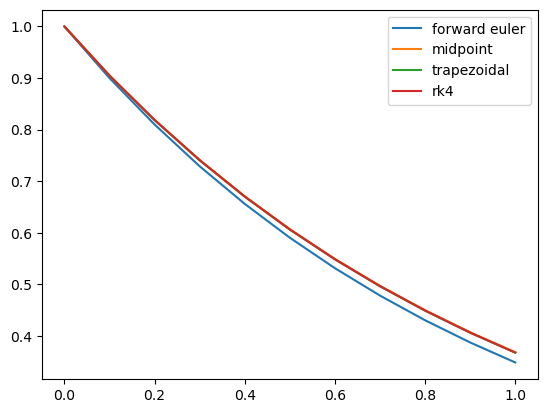

In [35]:
f = lambda t,y: -y
y0 = 1
tspan = (0,1)
k = 1e-1
fig, ax = plt.subplots()
label_list = ["forward euler", "midpoint", "trapezoidal", "rk4"]
solver_list ={"forward euler": forward_euler, "midpoint": midpoint, "trapezoidal": trapezoidal, "rk4": rk4}

for label in label_list:
    solver = solver_list[label]
    t, y = solver(f, tspan, y0, k) 
    ax.plot(t,y, label=label)
ax.legend()
plt.show()


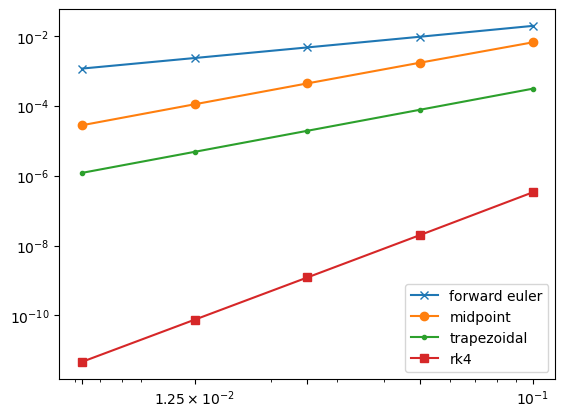

In [38]:
f = lambda t,y: -y
y0 = 1
y_exact = lambda t: np.exp(-t)
tspan = (0,1)

label_list = ["forward euler", "midpoint", "trapezoidal", "rk4"]
solver_list ={"forward euler": forward_euler, "midpoint": midpoint, "trapezoidal": trapezoidal, "rk4": rk4}
mark = {"forward euler":"x", "midpoint":"o", "trapezoidal":".", "rk4":"s"}

fig, ax = plt.subplots()
step = 0.1 * 0.5**np.arange(0,5)
for label in label_list:
    err_list = []
    solver = solver_list[label]
    for k in step:
        t, y = solver(f, tspan, y0, k) 
        error = np.linalg.norm(y-y_exact(t), ord=np.inf)
        err_list.append(error)
    ax.loglog(step, err_list, mark[label]+"-",label=label)

    
        

ax.legend()
ax.set_xticks(step)
#ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.show()

